In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread('DINGO3_Background.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
print(f"Min difference {np.min(img)}, Max difference {np.max(img)}")

Min difference 0, Max difference 255


In [3]:
input_img = cv2.imread("DINGO3_Frame0.jpg")
background_img = cv2.imread("DINGO3_Background.jpg")


In [4]:
gray_input = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
gray_background = cv2.cvtColor(background_img, cv2.COLOR_BGR2GRAY)

In [5]:
diff_img = cv2.absdiff(gray_input, gray_background)

In [6]:
threshold_value = 40
_, binary_mask = cv2.threshold(
    diff_img,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

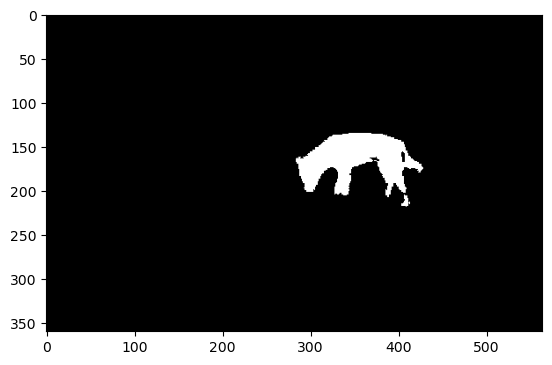

In [7]:
plt.imshow(binary_mask, cmap='gray')

In [8]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT, (5, 5))

dialated = cv2.dilate(binary_mask, kernel)
eroded = cv2.erode(dialated, kernel)

clean_mask = cv2.morphologyEx(binary_mask, 
                              cv2.MORPH_CLOSE, 
                              kernel)

In [9]:
mask_3ch = cv2.cvtColor(clean_mask, cv2.COLOR_GRAY2BGR) / 255.0
cut_out_img = (input_img * mask_3ch).astype(np.uint8)

In [10]:
result = input_img.copy()

for y in range(clean_mask.shape[0]):
    for x in range(clean_mask.shape[1]):
        if clean_mask[y,x] == 0:
            result[y,x] = 0

In [11]:
def compute_background_subtraced_img(input_img, background_img):
    # Convert to grayscale
    gray_input = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
    gray_background = cv2.cvtColor(background_img, cv2.COLOR_BGR2GRAY)

    # Compute difference
    diff_img = cv2.absdiff(gray_input, gray_background)

    # Normalisation
    diff_img = cv2.normalize(diff_img, None, 0, 255,
                             cv2.NORM_MINMAX).astype(np.uint8)
    
    # Thresholding
    _, binary_mask = cv2.threshold(diff_img, 40, 255,
                                   cv2.THRESH_BINARY)
    
    # Create strucituring element
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (5, 5))
    
    # Perform dialation and erosion
    clean_mask = cv2.morphologyEx(
        binary_mask, 
        cv2.MORPH_CLOSE, 
        kernel
    )

    # Apply the binary mask
    mask_3ch = cv2.cvtColor(clean_mask,
                             cv2.COLOR_GRAY2BGR) / 255.0
    cut_out_img = (input_img * mask_3ch).astype(np.uint8)
    return clean_mask, cut_out_img

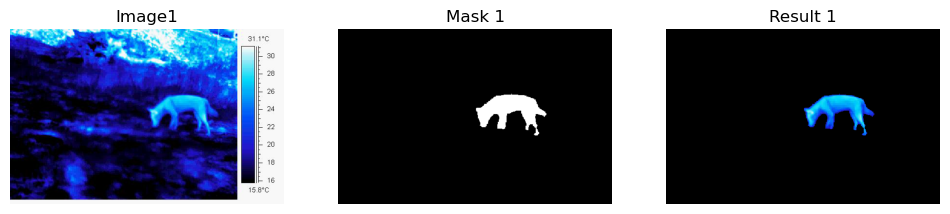

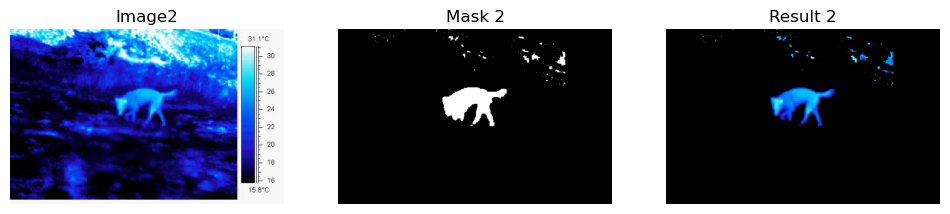

In [12]:
background_img = cv2.imread("DINGO3_Background.jpg")
dingo_img1 = cv2.imread("DINGO3_Frame0.jpg")
dingo_img2 = cv2.imread("DINGO3_Frame477.jpg")

dingo_images = [dingo_img1, dingo_img2]

for i, img in enumerate(dingo_images):

    mask, result = compute_background_subtraced_img(
        img,
        background_img
    )

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Image{i+1}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i+1}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(result)
    plt.title(f"Result {i+1}")
    plt.axis("off")

